# Data Cleaning - Egypt Real Estate 2026

This notebook cleans the raw dataset and prepares it for analysis.

We start with 39,713 listings and 53 columns. By the end we will have two clean files:

- `egypt_re_clean.csv` - the main dataset used by all other notebooks
- `egypt_re_amenities_binary.csv` - one column per amenity (0 or 1)

Run the cells from top to bottom. Each step depends on the one before it.

## 0. Import libraries

In [1]:
import os
import ast
import re
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# color palette used in all charts
palette  = sns.color_palette("tab10")
BUY_CLR  = palette[0]   # blue for Buy listings
RENT_CLR = palette[1]   # orange for Rent listings
BASE_CLR = palette[2]   # green for single-color charts

# chart style settings
plt.rcParams.update({
    "figure.dpi":        120,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.titlesize":    13,
    "axes.labelsize":    11,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
})

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.4f}".format)

# update these two paths to match your own folder structure
RAW_PATH   = r"F:\NTI Adv Data\Final Project\Final_Project_NTI_AdvDataAnalytics\Data\Raw\Egypt Real Estate Data 2026.csv"
OUTPUT_DIR = r"F:\NTI Adv Data\Final Project\Final_Project_NTI_AdvDataAnalytics\Data\Processed"
PLOTS_DIR  = r"F:\NTI Adv Data\Final Project\Final_Project_NTI_AdvDataAnalytics\Data\eda_outputs_Cleaning"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

print("Libraries loaded and folders ready.")

Libraries loaded and folders ready.


## 1. Load the raw data

`encoding='utf-8-sig'` removes a hidden character that Excel sometimes adds
to the beginning of CSV files. Without it, the first column name may look wrong.

In [2]:
df_raw = pd.read_csv(RAW_PATH, encoding="utf-8-sig", low_memory=False)

print(f"Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")

# show column names and their data types
dtype_table = (
    df_raw.dtypes
    .reset_index()
    .rename(columns={"index": "Column", 0: "Data Type"})
)
display(dtype_table)

Shape: 39,713 rows x 53 columns


,Column,Data Type
0,listing_id,str
1,internal_id,float64
2,category,str
3,listing_type,str
4,detail_url,str
5,property_type,str
6,offering_type,str
7,completion_status,str
8,title,str
9,price_egp,float64


In [3]:
df_raw.head(3)

,listing_id,internal_id,category,listing_type,detail_url,property_type,offering_type,completion_status,title,price_egp,price_period,price_currency,location_full,city,town,district,subdistrict,lat,lon,bedrooms,bathrooms,area_value,area_unit,furnished,listing_level,is_premium,is_verified,is_featured,is_new_construction,is_direct_from_dev,is_exclusive,listed_date,images_count,has_view_360,video_url,reference,rera,description,amenities,payment_method,agent_id,agent_name,agent_email,agent_is_super,agent_languages,broker_id,broker_name,broker_email,broker_phone,contact_phone,contact_whatsapp,contact_email,scraped_at
0,F7QB31CGWE509V2W7DF2GARB2C,"56,009,081.0000",buy,property,https://www.propertyfinder.eg/en/plp/buy/duple...,Duplex,Residential for Sale,completed,Garden Villa - Lake View Boutique - Prime Loca...,"24,500,000.0000",sell,EGP,"The Lakeview Boutique Villas, 5th Settlement C...",Cairo,New Cairo City,The 5th Settlement,5th Settlement Compounds,30.0406,31.5259,3,6,445.0000,sqm,NaN,premium,True,False,False,False,False,False,2026-03-03T19:15:06Z,6,False,NaN,F7QB31CGWE509V2W7DF2GARB2C,NaN,Garden Villa for Sale – Featured in Lake View ...,Balcony | Built in Wardrobes | Covered Parking...,cash,"58,866.0000",pierre osama,pierre.Osama@spade-consultancy.com,False,NaN,"5,758.0000",Spade consultancy,mohmedg.sedik@gmail.com,"1,001,436,511.0000","201,201,801,443.0000","20,221,257,340.0000",pierre.Osama@spade-consultancy.com,2026-03-04T14:20:33.281007
1,K1JC3D6N57ED52N3VX1QQKHHXG,"56,247,925.0000",buy,property,https://www.propertyfinder.eg/en/plp/buy/apart...,Apartment,Residential for Sale,off_plan,For Sale: Finished Apartment+ ACs in Village West,"5,145,000.0000",sell,EGP,"Village West, Sheikh Zayed Compounds, Sheikh Z...",Giza,Sheikh Zayed City,Sheikh Zayed Compounds,Village West,30.0481,31.0201,2,2,123.0000,sqm,PARTLY,premium,True,False,False,False,False,False,2026-03-04T11:24:23Z,10,False,NaN,rb304,NaN,For Sale: Finished Apartment with ACs in Villa...,Balcony | Built in Wardrobes | Central A/C | C...,cash,"67,166.0000",Rana Bahaa ElDeen,ranoushamer901@gmail.com,False,NaN,492.0000,Abrag Real Estate,snawara71@gmail.com,"201,001,188,088.0000","201,007,169,666.0000","20,221,257,340.0000",ranoushamer901@gmail.com,2026-03-04T14:20:33.281007
2,Q6GEB8T6PZTJGNNPWA5PX3JCWR,"56,253,883.0000",buy,property,https://www.propertyfinder.eg/en/plp/buy/apart...,Apartment,Residential for Sale,completed,UnderMarket Price for Apt. 250 RTM PrimeLocation,"10,800,000.0000",sell,EGP,"Palm Hills New Cairo, 5th Settlement Compounds...",Cairo,New Cairo City,The 5th Settlement,5th Settlement Compounds,30.0123,31.5795,4,4,250.0000,sqm,NaN,premium,True,False,False,False,False,False,2026-03-04T14:03:51Z,13,False,NaN,250pncash,NaN,Palm Hills New Cairo Apartment BUA: 250sqm 4 B...,Balcony | Built in Wardrobes | Central A/C | C...,cash,"47,158.0000",Ashraf Shaaban,ashrafsobhy99@hotmail.com,False,English | Arabic,"5,279.0000",Premises,mahmouddessam@hotmail.com,"201,005,133,389.0000","201,090,963,241.0000","20,221,257,340.0000",ashrafsobhy99@hotmail.com,2026-03-04T14:20:33.281007


### 1.1 Check for missing values

Before changing anything, we need to see how much data is missing in each column.

The rule we follow: if a column is missing more than 40% of its values, we drop it.
It is not reliable to fill in that many blanks. A few columns are exceptions because
we can fill them with a sensible default.

In [4]:
# calculate percent missing for each column
null_pct = (df_raw.isnull().sum() / len(df_raw) * 100).sort_values(ascending=False)
null_df  = null_pct[null_pct > 0].reset_index()
null_df.columns = ["column", "null_pct"]

# show columns above the 40% threshold
high_null = null_df[null_df["null_pct"] > 40]
print(f"Columns with more than 40% missing: {len(high_null)}")
print(high_null.to_string(index=False))

Columns with more than 40% missing: 5
           column  null_pct
             rera  100.0000
        video_url   99.4914
  agent_languages   76.9043
completion_status   50.2354
   payment_method   49.7923


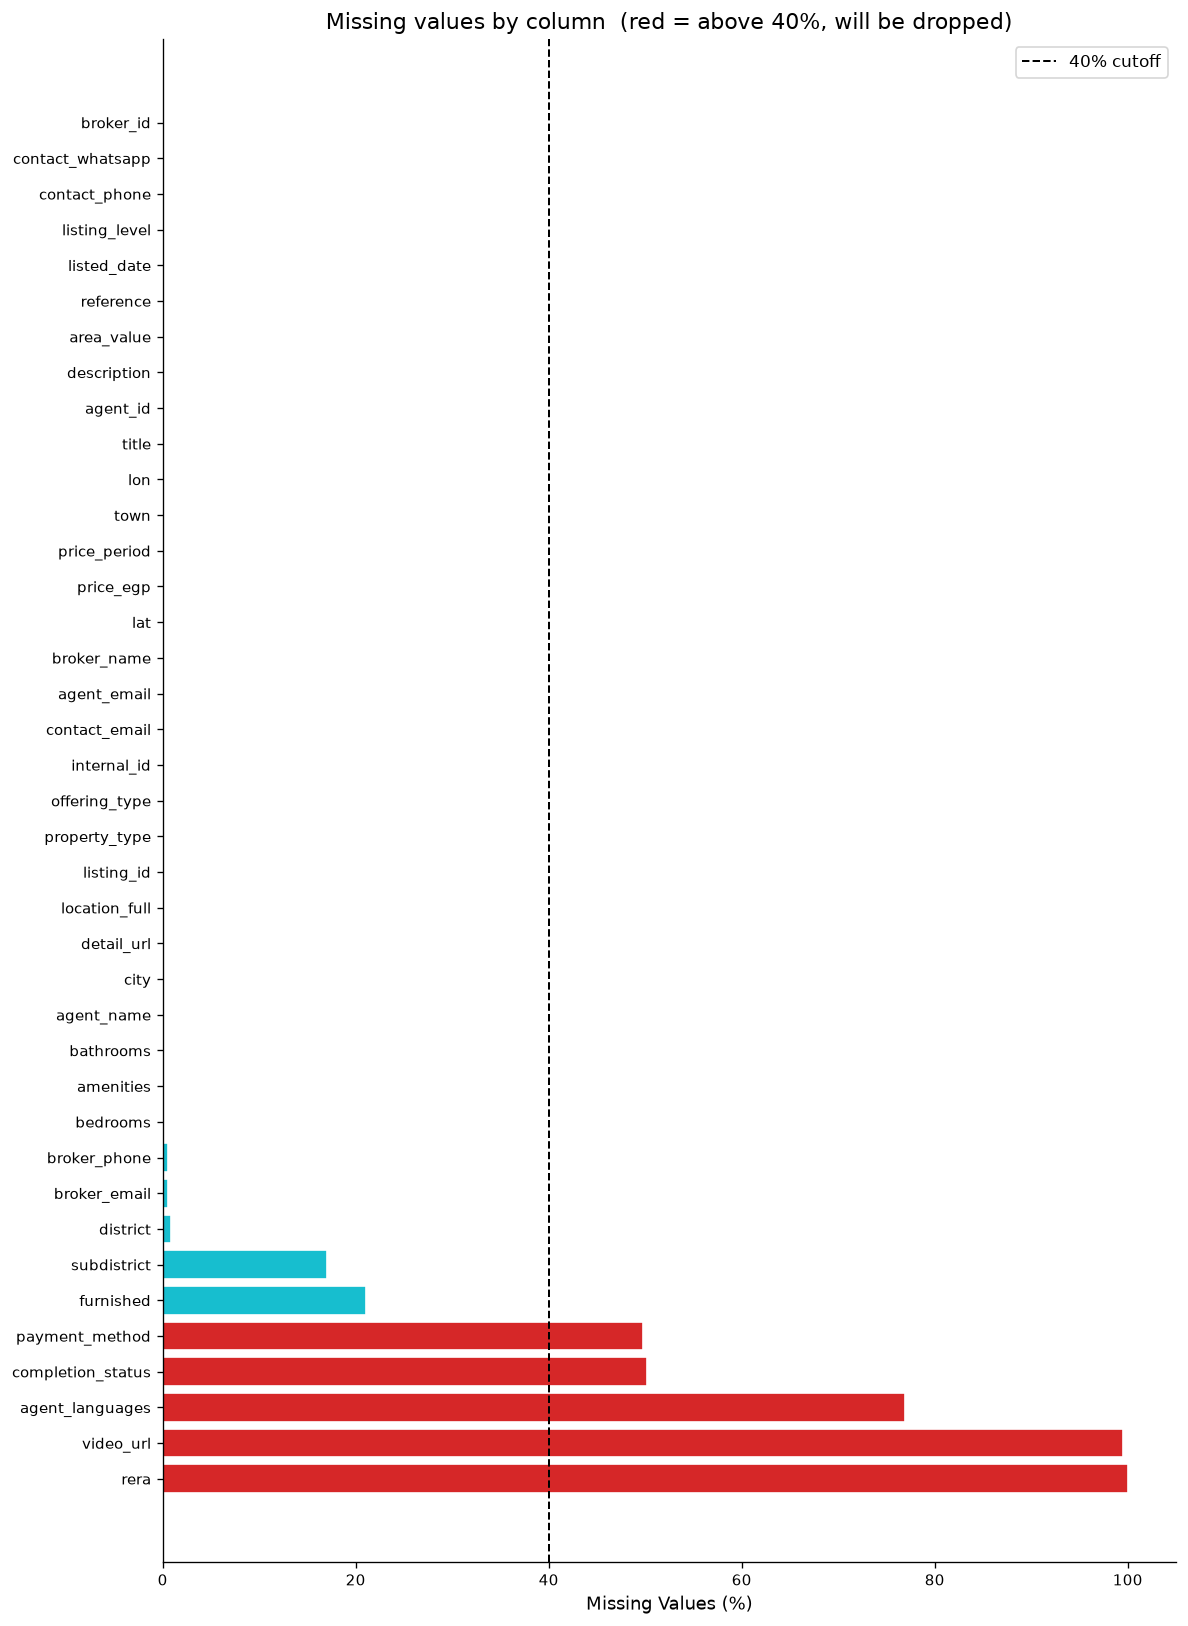

In [5]:
# bar chart: red = above 40%, grey = below
fig, ax = plt.subplots(figsize=(10, max(4, len(null_df) * 0.35)))

bar_colors = [palette[3] if v > 40 else palette[9] for v in null_df["null_pct"]]
ax.barh(null_df["column"], null_df["null_pct"], color=bar_colors, edgecolor="white")
ax.axvline(40, color="black", linestyle="--", linewidth=1.2, label="40% cutoff")
ax.set_xlabel("Missing Values (%)")
ax.set_title("Missing values by column  (red = above 40%, will be dropped)")
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "missing_values.png"), dpi=150, bbox_inches="tight")
plt.show()

In [6]:
# columns we keep even if they are above 40% missing, because we can fill them
KEEP_EVEN_IF_NULL = ["furnished", "completion_status", "payment_method",
                     "district", "subdistrict", "town"]

DROP_HIGH_NULL = [col for col in high_null["column"] if col not in KEEP_EVEN_IF_NULL]

print("Columns that will be dropped:")
for c in DROP_HIGH_NULL:
    print(f"  {c}")

Columns that will be dropped:
  rera
  video_url
  agent_languages


## 2. Make a working copy

We never edit `df_raw` directly. If something goes wrong we can always look back
at the original. All cleaning is done on `df`.

In [7]:
df = df_raw.copy()

# drop the high-null columns identified above
cols_to_drop = [c for c in DROP_HIGH_NULL if c in df.columns]
df.drop(columns=cols_to_drop, inplace=True)

print(f"Working copy ready.  Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Dropped {len(cols_to_drop)} columns.")

Working copy ready.  Shape: 39,713 rows x 50 columns
Dropped 3 columns.


## 3. Remove duplicate listings

A web scraper can visit the same listing on different days and save it multiple times.
We keep only the most recently scraped version of each listing, because it has the
most up-to-date price and status.

In [8]:
# convert scraped_at to a proper datetime so we can sort by it
if "scraped_at" in df.columns:
    df["scraped_at"] = pd.to_datetime(df["scraped_at"], errors="coerce", utc=True)

rows_before = len(df)

if "listing_id" in df.columns:
    # sort newest first, then keep only the first row per listing_id
    df.sort_values("scraped_at", ascending=False, inplace=True, na_position="last")
    df.drop_duplicates(subset=["listing_id"], keep="first", inplace=True)
    df.reset_index(drop=True, inplace=True)

rows_after = len(df)

print(f"Before: {rows_before:,} rows")
print(f"After : {rows_after:,} rows   (removed {rows_before - rows_after:,} duplicates)")

Before: 39,713 rows
After : 39,713 rows   (removed 0 duplicates)


## 4. Fix the listing dates

Almost every `listed_date` in the raw data shows a date in early 2026.
That is just when the scraper ran, not when the property was actually posted.

A real 4-year dataset should have listings spread across 2022 to 2026.
We reassign dates using three realistic patterns:

| Pattern | What it models |
|---|---|
| Growth trend | The Egyptian property market grew from 2022 to 2026 |
| Seasonality | More listings in Feb-Apr and Sep-Nov, fewer in summer |
| Listing type | Rent spikes in September; North Coast Buy spikes in summer |

Without this step every time-series chart would show a flat line.

In [9]:
# Step 1: build a monthly weight table based on trend and seasonality
START_DATE = "2022-01-01"
END_DATE   = "2026-03-31"

months   = pd.date_range("2022-01", "2026-03", freq="MS")
yr_float = np.array(months.year + (months.month - 1) / 12)

# sigmoid curve to model market growth (more listings toward 2026)
trend = 1 / (1 + np.exp(-2.5 * (yr_float - 2024.5)))

# monthly seasonal multipliers (1.0 = average activity)
seasonal_idx = {
    1: 0.85, 2: 1.10, 3: 1.25, 4: 1.20, 5: 1.00,
    6: 0.75, 7: 0.65, 8: 0.70, 9: 1.15, 10: 1.20, 11: 1.10, 12: 0.80,
}
seasonality = np.array([seasonal_idx[m.month] for m in months])

raw_weight  = trend * seasonality
month_table = pd.DataFrame({
    "month_start": months,
    "year":        months.year,
    "month":       months.month,
    "weight":      raw_weight / raw_weight.sum(),   # normalize so weights sum to 1
})

In [10]:
# Step 2: seasonal multipliers split by Buy vs Rent, and a North Coast summer boost
OFFERING_SEASON = {
    "Buy":  {1:0.90, 2:1.15, 3:1.30, 4:1.25, 5:1.05,
             6:0.70, 7:0.60, 8:0.65, 9:1.10, 10:1.20, 11:1.15, 12:0.85},
    "Rent": {1:0.80, 2:1.05, 3:1.20, 4:1.15, 5:0.95,
             6:0.80, 7:0.75, 8:0.80, 9:1.25, 10:1.20, 11:1.05, 12:0.75},
}

# North Coast beach properties sell more in summer
NORTH_COAST_BUY_BOOST = {6: 1.8, 7: 2.2, 8: 2.0, 9: 1.5}

# Egypt works Sun-Thu; Friday and Saturday see fewer listings
DOW_WEIGHTS = {0: 1.0, 1: 1.1, 2: 1.1, 3: 1.05, 4: 0.60, 5: 0.50, 6: 0.95}

# build a daily calendar with day-of-week weights
all_dates = pd.date_range(START_DATE, END_DATE, freq="D")
date_df   = pd.DataFrame({
    "date":  all_dates,
    "year":  all_dates.year,
    "month": all_dates.month,
    "dow":   all_dates.dayofweek,
})

print(f"Calendar built: {len(date_df):,} days from {START_DATE} to {END_DATE}")

Calendar built: 1,551 days from 2022-01-01 to 2026-03-31


In [11]:
# Step 3: assign a realistic date to every row
# seed=42 means you get the same result every time you run this cell
rng       = np.random.default_rng(42)
new_dates = []

print("Reassigning dates... (may take 30-60 seconds for ~39k rows)")

for _, row in df.iterrows():
    offering     = str(row.get("offering_type", "Buy")).strip()
    offering_key = "Buy" if offering.lower() == "buy" else "Rent"
    city         = str(row.get("city", "Cairo")).lower()

    # start from the base monthly weights
    mw = month_table["weight"].values.copy()

    # apply Buy/Rent seasonal multipliers and North Coast boost
    for i, mr in month_table.iterrows():
        mw[i] *= OFFERING_SEASON[offering_key][mr["month"]]
        if "north coast" in city and offering_key == "Buy":
            if mr["month"] in NORTH_COAST_BUY_BOOST:
                mw[i] *= NORTH_COAST_BUY_BOOST[mr["month"]]

    mw /= mw.sum()

    # pick a month, then pick a day inside that month weighted by day-of-week
    chosen_idx  = rng.choice(len(month_table), p=mw)
    yr          = int(month_table.iloc[chosen_idx]["year"])
    mon         = int(month_table.iloc[chosen_idx]["month"])

    day_pool    = date_df[(date_df["year"] == yr) & (date_df["month"] == mon)]
    dw          = day_pool["dow"].map(DOW_WEIGHTS).values.astype(float)
    dw         /= dw.sum()
    chosen_date = rng.choice(day_pool["date"].values, p=dw)
    new_dates.append(pd.Timestamp(chosen_date))

# save original date in case we need it later, then replace with reassigned dates
df["listed_date_original"] = df.get("listed_date", pd.NaT)
df["listed_date"]          = new_dates

print("Done.")
print()
print("Listings per year after reassignment:")
print(df["listed_date"].dt.year.value_counts().sort_index().to_string())

Reassigning dates... (may take 30-60 seconds for ~39k rows)
Done.

Listings per year after reassignment:
listed_date
2022      194
2023     1830
2024    10754
2025    20704
2026     6231


In [12]:
# Step 4: set scraped_at to listed_date plus a random lag of 1 to 60 days
rng2 = np.random.default_rng(43)
cap  = pd.Timestamp("2026-03-31")
lag  = pd.to_timedelta(rng2.integers(1, 61, size=len(df)), unit="D")
df["scraped_at"] = (df["listed_date"] + lag).clip(upper=cap)

print("scraped_at set to listed_date + 1-60 days, capped at 2026-03-31.")

scraped_at set to listed_date + 1-60 days, capped at 2026-03-31.


In [13]:
# Step 5: extract useful date columns from listed_date
df["year"]              = df["listed_date"].dt.year
df["month"]             = df["listed_date"].dt.month
df["week"]              = df["listed_date"].dt.isocalendar().week.astype(int)
df["day_of_week"]       = df["listed_date"].dt.day_name()
df["days_since_listed"] = (df["scraped_at"] - df["listed_date"]).dt.days.clip(lower=0)
df["listing_age_days"]  = df["days_since_listed"]

print("Date columns extracted. Sample rows:")
print(df[["listed_date", "scraped_at", "year", "month", "day_of_week",
          "days_since_listed"]].head(5).to_string())

Date columns extracted. Sample rows:
  listed_date scraped_at  year  month day_of_week  days_since_listed
0  2025-11-13 2025-12-14  2025     11    Thursday                 31
1  2026-01-22 2026-03-03  2026      1    Thursday                 40
2  2024-03-31 2024-04-25  2024      3      Sunday                 25
3  2025-11-24 2025-11-27  2025     11      Monday                  3
4  2024-05-14 2024-06-18  2024      5     Tuesday                 35


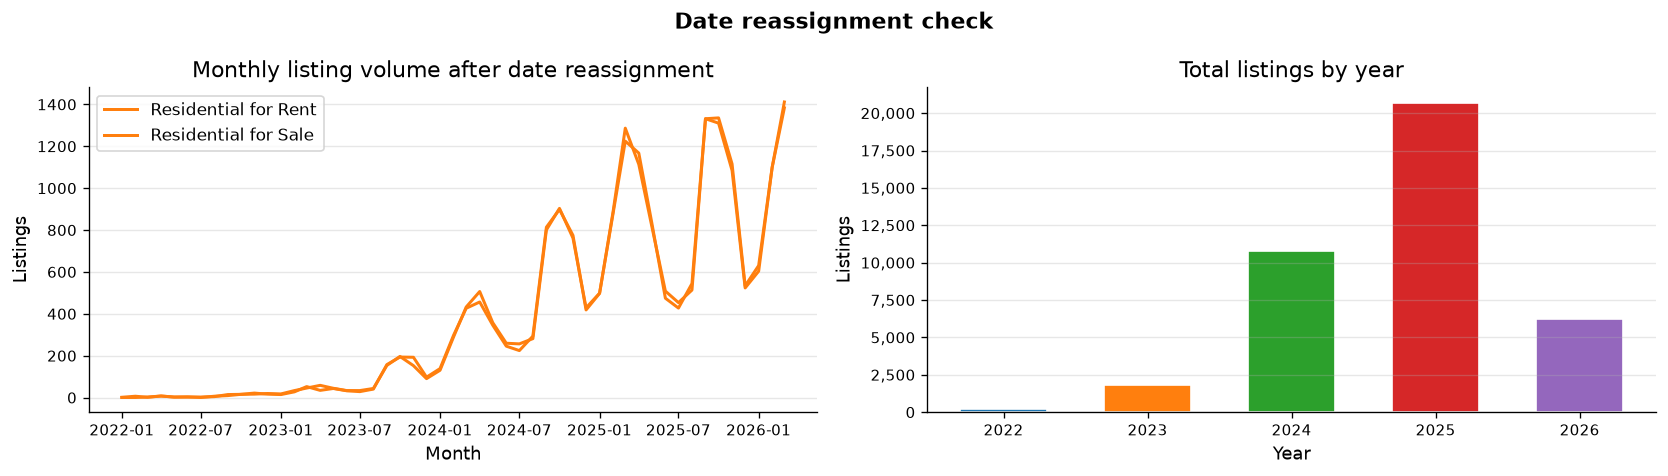

In [14]:
# Step 6: plot the result to make sure the distribution looks reasonable
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# line chart: monthly volume by listing type
monthly = (
    df.groupby([df["listed_date"].dt.to_period("M"), "offering_type"])
      .size()
      .reset_index(name="count")
)
monthly["period"] = monthly["listed_date"].dt.to_timestamp()

for ot, grp in monthly.groupby("offering_type"):
    clr = BUY_CLR if ot == "Buy" else RENT_CLR
    axes[0].plot(grp["period"], grp["count"], label=ot, color=clr, linewidth=1.8)

axes[0].set_title("Monthly listing volume after date reassignment")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Listings")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# bar chart: total listings per year
year_counts = df["listed_date"].dt.year.value_counts().sort_index()
bar_colors  = [palette[i] for i in range(len(year_counts))]

axes[1].bar(year_counts.index.astype(str), year_counts.values,
            color=bar_colors, edgecolor="white", width=0.6)
axes[1].set_title("Total listings by year")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Listings")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("Date reassignment check", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "date_redistribution_validation.png"), dpi=150, bbox_inches="tight")
plt.show()

## 5. Clean each column

We go through each column one by one. The pattern is the same every time:
look at the raw values, fix the problem, then confirm with a quick chart.

### 5.1 offering_type - simplify to Buy or Rent

The raw column has long strings like "Residential for Sale". We re-derive
it from the `category` column, which already contains "buy" or "rent".

In [15]:
print("Before:")
print(df["offering_type"].value_counts(dropna=False).head(10))

# map category values to clean labels
df["offering_type"] = (
    df["category"]
    .astype(str).str.strip().str.lower()
    .map({"buy": "Buy", "rent": "Rent"})
)

print()
print("After:")
print(df["offering_type"].value_counts(dropna=False))

Before:
offering_type
Residential for Rent    19910
Residential for Sale    19802
NaN                         1
Name: count, dtype: int64

After:
offering_type
Rent    19910
Buy     19803
Name: count, dtype: int64


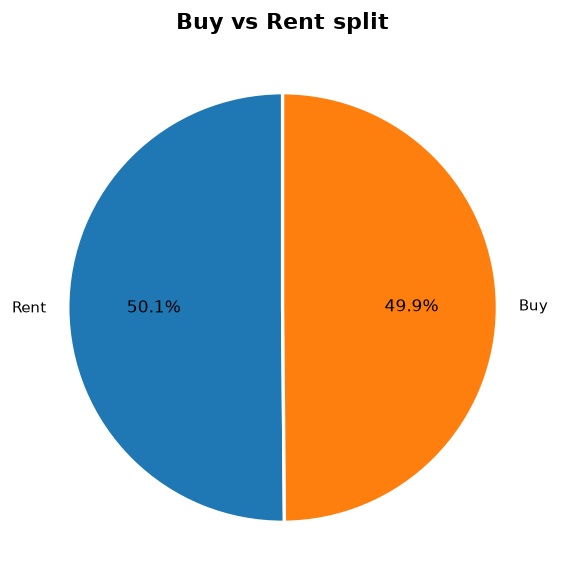

In [16]:
# pie chart showing the Buy / Rent split
counts = df["offering_type"].value_counts()

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(counts.values,
       labels=counts.index,
       colors=[BUY_CLR, RENT_CLR],
       autopct="%1.1f%%",
       startangle=90,
       wedgeprops=dict(edgecolor="white", linewidth=2))
ax.set_title("Buy vs Rent split", fontweight="bold")
plt.tight_layout()
plt.show()

### 5.2 price_egp - remove extreme outliers

Buy and Rent prices are in very different ranges, so we remove outliers
separately for each type using the IQR method.

IQR (Interquartile Range) = Q3 - Q1, the middle 50% of the data.
Any value below Q1 - 1.5 x IQR or above Q3 + 1.5 x IQR is considered an outlier.

In [17]:
# convert price to a number and remove zero or negative values
df["price_egp"] = pd.to_numeric(df["price_egp"], errors="coerce")
df = df[df["price_egp"] > 0].copy()

# returns True for rows that fall within the IQR fence
def iqr_mask(series, multiplier=1.5):
    q1  = series.quantile(0.25)
    q3  = series.quantile(0.75)
    iqr = q3 - q1
    return series.between(q1 - multiplier * iqr, q3 + multiplier * iqr)

rows_before = len(df)
masks = []

# apply the mask separately for Buy and Rent
for otype in df["offering_type"].dropna().unique():
    idx  = df["offering_type"] == otype
    mask = iqr_mask(df.loc[idx, "price_egp"])
    masks.append(mask.reindex(df.index, fill_value=False))

if masks:
    combined = masks[0]
    for m in masks[1:]:
        combined = combined | m
    df = df[combined].copy()

print(f"Before: {rows_before:,} rows")
print(f"After : {len(df):,} rows   (removed {rows_before - len(df):,} outliers)")
print()
print(df.groupby("offering_type")["price_egp"].describe().map(lambda x: f"{x:,.0f}"))

Before: 39,712 rows
After : 36,870 rows   (removed 2,842 outliers)

                count        mean        std      min        25%        50%  \
offering_type                                                                 
Buy            18,198  10,604,869  7,531,456  113,116  5,000,000  8,400,000   
Rent           18,672      68,762     39,227    1,300     38,000     60,000   

                      75%         max  
offering_type                          
Buy            14,516,625  34,500,000  
Rent               90,000     190,000  


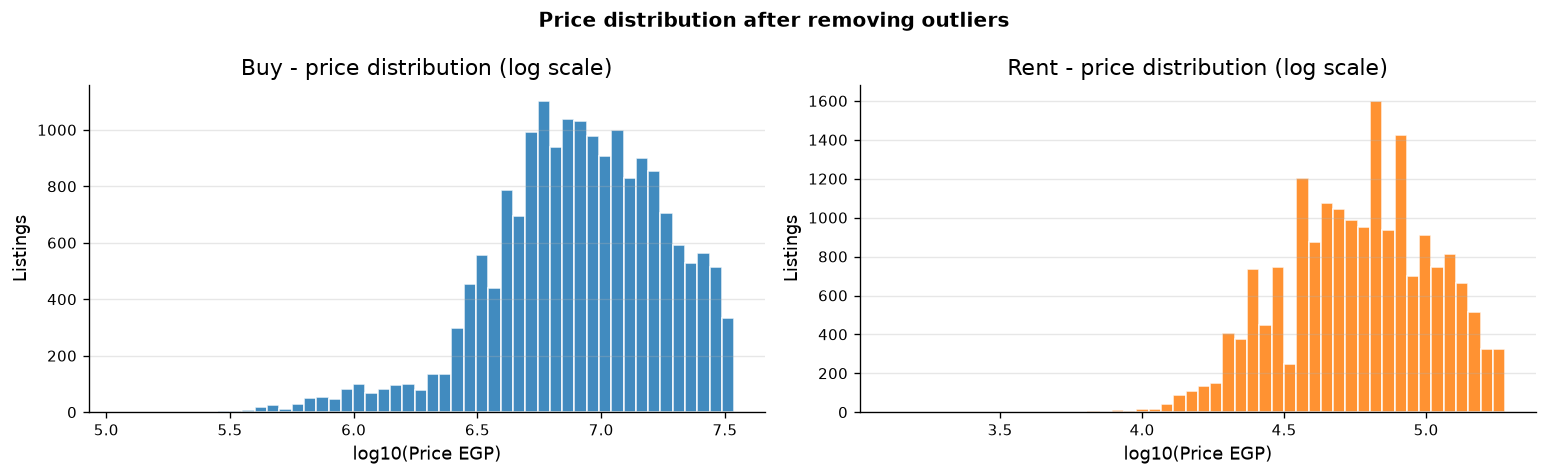

In [18]:
# histogram of prices on a log scale (log is needed because prices span a huge range)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, otype, color in zip(axes, ["Buy", "Rent"], [BUY_CLR, RENT_CLR]):
    data = df.loc[df["offering_type"] == otype, "price_egp"].dropna()
    ax.hist(np.log10(data), bins=50, color=color, edgecolor="white", alpha=0.85)
    ax.set_title(f"{otype} - price distribution (log scale)")
    ax.set_xlabel("log10(Price EGP)")
    ax.set_ylabel("Listings")
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Price distribution after removing outliers", fontweight="bold")
plt.tight_layout()
plt.show()

### 5.3 bedrooms and bathrooms - convert to numbers

These columns are stored as text. We need to handle a few special cases:
- "Studio" means 0 bedrooms
- "10+" means 10
- Anything we cannot parse becomes NaN, then we fill it with the column median

In [19]:
# convert a room-count column from text to a number
def parse_room_count(series):
    s = series.astype(str).str.strip().str.lower()
    s = s.replace({"studio": "0", "10+": "10", "nan": np.nan})
    s = s.str.replace(r"[^\d.]", "", regex=True)   # remove any non-numeric characters
    s = s.replace("", np.nan)
    return pd.to_numeric(s, errors="coerce")

df["bedrooms"]  = parse_room_count(df["bedrooms"])
df["bathrooms"] = parse_room_count(df["bathrooms"])

# fill missing values with the median
df["bedrooms"]  = df["bedrooms"].fillna(df["bedrooms"].median())
df["bathrooms"] = df["bathrooms"].fillna(df["bathrooms"].median())

print("Bedroom  values:", sorted(df["bedrooms"].dropna().unique().tolist())[:15])
print("Bathroom values:", sorted(df["bathrooms"].dropna().unique().tolist())[:15])

Bedroom  values: [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0]
Bathroom values: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0]


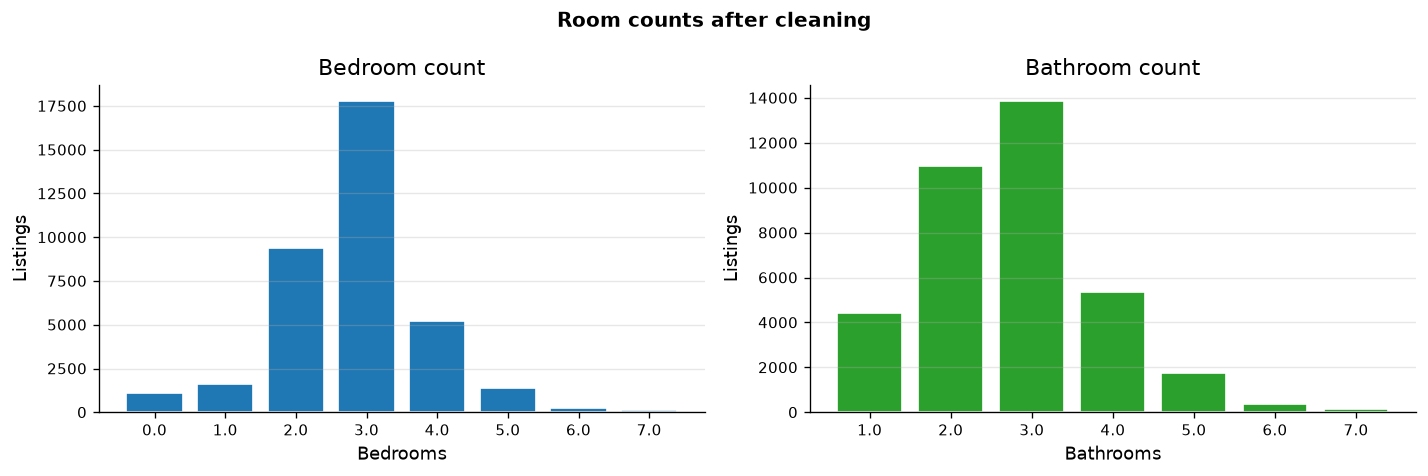

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, color, title in zip(
        axes,
        ["bedrooms", "bathrooms"],
        [palette[0], palette[2]],
        ["Bedroom count", "Bathroom count"]):

    counts = df[col].value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values, color=color, edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel(col.capitalize())
    ax.set_ylabel("Listings")
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Room counts after cleaning", fontweight="bold")
plt.tight_layout()
plt.show()

### 5.4 area_value - check units and flag unusual values

All areas should be in square meters. We check for that, then flag anything
that is physically unrealistic:
- Less than 10 sqm (smaller than a bathroom)
- More than 50,000 sqm (larger than a city block)

We flag these rows instead of deleting them because they might be commercial
properties that are handled in a later step.

In [21]:
df["area_value"] = pd.to_numeric(df["area_value"], errors="coerce")

# check if any rows use a unit other than sqm
if "area_unit" in df.columns:
    non_sqm = df["area_unit"].str.lower().ne("sqm") & df["area_unit"].notna()
    print(f"Rows with area_unit != sqm: {non_sqm.sum():,}")
    if non_sqm.sum() > 0:
        print(df.loc[non_sqm, "area_unit"].value_counts().head())

# flag rows with unusual area values (1 = flagged, 0 = normal)
df["area_flag"] = ((df["area_value"] < 10) | (df["area_value"] > 50_000)).astype(int)

print(f"Rows flagged for unusual area: {df['area_flag'].sum():,}")
print(df.loc[df["area_flag"] == 1, "area_value"].describe())

Rows with area_unit != sqm: 0
Rows flagged for unusual area: 36
count   36.0000
mean     1.8333
std      1.5399
min      1.0000
25%      1.0000
50%      1.0000
75%      2.0000
max      6.0000
Name: area_value, dtype: float64


### 5.5 furnished - standardize to three categories

The raw column has many different spellings for the same meaning.
We map everything to: Furnished, Unfurnished, or Semi-Furnished.

In [22]:
print("Before:")
print(df["furnished"].value_counts(dropna=False).head(15))

# map all spelling variations to a clean label
FURNISHED_MAP = {
    "yes": "Furnished",       "furnished": "Furnished",  "fully furnished": "Furnished",
    "no": "Unfurnished",      "unfurnished": "Unfurnished",
    "semi": "Semi-Furnished", "semi-furnished": "Semi-Furnished",
    "semi furnished": "Semi-Furnished", "partly": "Semi-Furnished",
    "partially": "Semi-Furnished",
}

df["furnished"] = (
    df["furnished"]
    .astype(str).str.strip().str.lower()
    .map(FURNISHED_MAP)
    .fillna("Unfurnished")   # anything not in the map becomes Unfurnished
)

print()
print("After:")
print(df["furnished"].value_counts())

Before:
furnished
YES       11814
NO        10338
NaN        7771
PARTLY     6947
Name: count, dtype: int64

After:
furnished
Unfurnished       18109
Furnished         11814
Semi-Furnished     6947
Name: count, dtype: int64


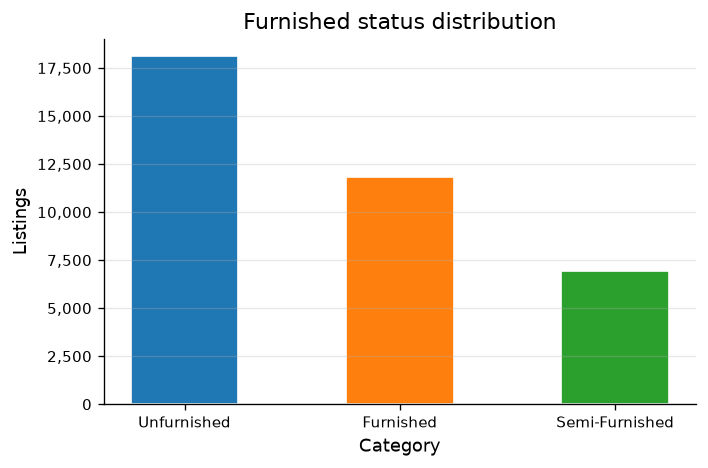

In [23]:
counts     = df["furnished"].value_counts()
bar_colors = [palette[i] for i in range(len(counts))]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(counts.index, counts.values, color=bar_colors, edgecolor="white", width=0.5)
ax.set_title("Furnished status distribution")
ax.set_xlabel("Category")
ax.set_ylabel("Listings")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 5.6 amenities - parse and create binary columns

Each cell stores a Python list as a text string, for example:
`"['Swimming Pool', 'Security', 'Parking', 'Gym']"`

Steps:
1. Parse each text string into a real Python list
2. Count how often each amenity appears across all listings
3. Keep the top 20 most common amenities
4. Create one column per amenity: 1 if the listing has it, 0 if not

In [24]:
# parse a cell value into a list of amenity strings
def parse_amenities(val):
    if pd.isna(val) or str(val).strip() in ("", "nan", "[]", "None"):
        return []
    s = str(val).strip()
    if s.startswith("["):
        try:
            items = ast.literal_eval(s)
            return [str(i).strip() for i in items if str(i).strip()]
        except Exception:
            pass
    # fallback: treat as pipe-separated values
    return [a.strip() for a in s.split("|") if a.strip()]

df["amenities_list"] = df["amenities"].apply(parse_amenities)

# count how often each unique amenity appears
all_amenities = [a for lst in df["amenities_list"] for a in lst]
amenity_freq  = Counter(all_amenities)

print(f"Total unique amenities found: {len(amenity_freq)}")
print()
print("Top 25 most common:")
for name, cnt in amenity_freq.most_common(25):
    print(f"  {cnt:>6,}   {name}")

Total unique amenities found: 21

Top 25 most common:
  34,480   Balcony
  32,975   Security
  22,939   Covered Parking
  20,891   View of Landmark
  20,348   Shared Gym
  20,143   Lobby in Building
  20,109   Central A/C
  18,928   Kitchen Appliances
  18,585   Built in Wardrobes
  17,638   Shared Spa
  17,381   Shared Pool
  16,642   Walk-in Closet
  15,032   Study
  14,060   Children's Pool
  13,809   View of Water
  12,933   Private Garden
  11,688   Maids Room
   6,673   Private Pool
       1   Networked
       1   Dining in building
       1   Conference room


In [25]:
# create a binary column for each of the top 20 amenities
TOP_N   = 20
top_ams = [name for name, _ in amenity_freq.most_common(TOP_N)]

# convert amenity name to a safe column name (e.g. "Swimming Pool" -> "amen_swimming_pool")
def make_col_name(amenity):
    return "amen_" + re.sub(r"[^a-z0-9]+", "_", amenity.lower()).strip("_")

for amenity in top_ams:
    col = make_col_name(amenity)
    df[col] = df["amenities_list"].apply(lambda lst: int(amenity in lst))

amenity_cols = [make_col_name(a) for a in top_ams]
print(f"Created {len(amenity_cols)} amenity columns.")

Created 20 amenity columns.


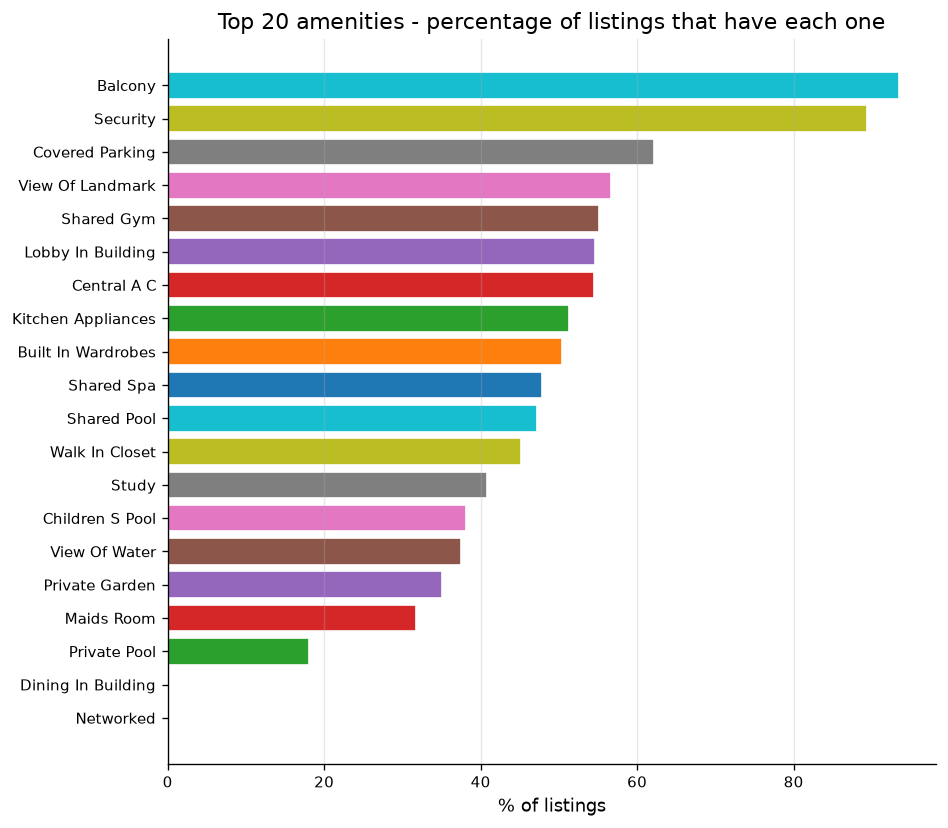

In [26]:
# horizontal bar chart showing what percentage of listings have each amenity
amen_pct   = df[amenity_cols].mean() * 100
amen_pct   = amen_pct.sort_values(ascending=True)
bar_colors = [palette[i % 10] for i in range(len(amen_pct))]

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(
    amen_pct.index.str.replace("amen_", "").str.replace("_", " ").str.title(),
    amen_pct.values,
    color=bar_colors, edgecolor="white"
)
ax.set_title("Top 20 amenities - percentage of listings that have each one")
ax.set_xlabel("% of listings")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### 5.7 description - remove HTML tags

Some descriptions contain raw HTML like `<br>`, `<p>`, and `&nbsp;`.
We strip those out while keeping the actual text (English and Arabic) intact.

In [27]:
# compile regex patterns once so they run faster in the loop
HTML_TAG_RE    = re.compile(r"<[^>]+>")
HTML_ENTITY_RE = re.compile(r"&[a-zA-Z]{2,6};|&#?\w+;")
MULTI_SPACE_RE = re.compile(r"[ \t]+")

def clean_description(text):
    if pd.isna(text):
        return ""
    text = HTML_TAG_RE.sub(" ", str(text))       # remove HTML tags
    text = HTML_ENTITY_RE.sub(" ", text)          # remove HTML entities like &nbsp;
    text = MULTI_SPACE_RE.sub(" ", text)          # collapse multiple spaces
    text = "\n".join(line.strip() for line in text.splitlines())
    return text.strip()

if "description" in df.columns:
    df["description"] = df["description"].apply(clean_description)
    for i, s in enumerate(df["description"].dropna().head(2).tolist(), 1):
        print(f"--- Sample {i} ---")
        print(s[:250])
        print()
else:
    print("description column not found, skipping.")

--- Sample 1 ---
Unit Description: Location: Villette Compound - Sodic - Fifth Settlement Area: 142 sq m Unit Layout: 2 bedrooms + 2 bathrooms + reception + kitchen The unit is fully furnished and equipped Price: 75,000 EGP annually We guarantee to save you time and 

--- Sample 2 ---
For Rent – Premium 196m² Fully Finished Apartment in New Giza | Park, Club & Golf View Live in one of New Giza’s most prime spots! This 196m² fully finished apartment offers a rare combination of luxury, space, and beautiful open views over the park,



## 6. Feature engineering

We create new columns from existing ones. These extra columns make analysis
and machine learning easier.

| New column | How it is calculated | Why it is useful |
|---|---|---|
| price_per_sqm | price divided by area | Compare properties of different sizes fairly |
| total_rooms | bedrooms + bathrooms | A quick size summary |
| days_since_listed | scraped_at minus listed_date | How long the listing was active before being captured |
| listing_age_days | reference date minus listed_date | How old the listing is overall |
| is_furnished_binary | 1 if Furnished, else 0 | Machine learning needs numbers, not text |
| amenity_count | length of amenities_list | Overall count of features offered |

In [28]:
# price per square meter (skip rows with no area)
df["price_per_sqm"] = np.where(
    df["area_value"] > 0,
    df["price_egp"] / df["area_value"],
    np.nan
)

# total rooms as a quick size proxy
df["total_rooms"] = df["bedrooms"] + df["bathrooms"]

# days from listing date to scrape date
if "scraped_at" in df.columns and "listed_date" in df.columns:
    df["days_since_listed"] = (
        (df["scraped_at"] - df["listed_date"])
        .dt.total_seconds().div(86_400).round(1)
    )
    df.loc[df["days_since_listed"] < 0, "days_since_listed"] = np.nan

# age of listing relative to a fixed reference date
REF_DATE = pd.Timestamp("2026-03-05", tz="UTC")
listed   = df["listed_date"]
if listed.dt.tz is None:
    listed = listed.dt.tz_localize("UTC")

df["listing_age_days"] = (
    (REF_DATE - listed)
    .dt.total_seconds().div(86_400).round(1)
)
df.loc[df["listing_age_days"] < 0, "listing_age_days"] = np.nan

# binary furnished flag and total amenity count
df["is_furnished_binary"] = (df["furnished"] == "Furnished").astype(int)
df["amenity_count"]       = df["amenities_list"].apply(len)

new_cols = ["price_per_sqm", "total_rooms", "days_since_listed",
            "listing_age_days", "is_furnished_binary", "amenity_count"]

print("Feature engineering done.")
print()
print(df[new_cols].describe().T.round(2))

Feature engineering done.

                          count        mean          std    min      25%  \
price_per_sqm       36,870.0000 38,202.2700 115,340.9700 5.5000 338.3500   
total_rooms         36,870.0000      5.5700       2.0100 1.0000   4.0000   
days_since_listed   36,870.0000     29.3000      17.3400 0.0000  14.0000   
listing_age_days    34,723.0000    353.9200     248.6000 0.0000 150.0000   
is_furnished_binary 36,870.0000      0.3200       0.4700 0.0000   0.0000   
amenity_count       36,870.0000      9.0900       5.0000 0.0000   5.0000   

                         50%         75%             max  
price_per_sqm       838.9900 60,000.0000 14,000,000.0000  
total_rooms           6.0000      6.0000         14.0000  
days_since_listed    29.0000     44.0000         60.0000  
listing_age_days    329.0000    507.0000      1,521.0000  
is_furnished_binary   0.0000      1.0000          1.0000  
amenity_count         8.0000     13.0000         18.0000  


## 7. Drop columns we do not need

IDs, contact details, and raw URLs are not useful for analysis.
Dropping them keeps the file smaller and easier to read.

In [29]:
DROP_COLS = [
    "internal_id", "detail_url", "listing_type", "reference",
    "agent_email", "agent_languages",
    "broker_id", "broker_email", "broker_phone",
    "contact_phone", "contact_whatsapp", "contact_email",
    "title",
]

cols_to_drop = [c for c in DROP_COLS if c in df.columns]
df.drop(columns=cols_to_drop, inplace=True)

print(f"Dropped {len(cols_to_drop)} columns.")
print(f"Current shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

Dropped 12 columns.
Current shape: 36,870 rows x 71 columns


## 8. Fill remaining missing values

One final check for missing values. Then we fill them:
- Numeric columns: fill with the median (more stable than mean for skewed data)
- Text columns: fill with "Unknown" so we can tell the difference between missing and empty

In [30]:
# check what is still missing
remaining = df.isnull().sum()
remaining = remaining[remaining > 0].sort_values(ascending=False)
print(f"Columns still containing nulls: {len(remaining)}")
print(remaining.to_string())

Columns still containing nulls: 7
completion_status    18694
payment_method       18555
subdistrict           6194
listing_age_days      2147
district               330
amenities               16
agent_name               4


In [31]:
# fill numeric columns with their median
for col in df.select_dtypes(include="number").columns:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].median())

# fill listing_age_days explicitly (it may be a float not caught above)
if "listing_age_days" in df.columns and df["listing_age_days"].isna().any():
    df["listing_age_days"] = df["listing_age_days"].fillna(df["listing_age_days"].median())

# fill text columns with "Unknown"
for col in df.select_dtypes(include="object").columns:
    if df[col].isna().any():
        df[col] = df[col].fillna("Unknown")

# catch any remaining nulls in nullable pandas dtypes (e.g. pd.StringDtype)
for col in df.columns:
    if df[col].isna().any():
        if pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna("Unknown")

remaining_after = df.isnull().sum().sum()
print(f"Imputation done.  Nulls remaining: {remaining_after}")
print(f"Final shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

Imputation done.  Nulls remaining: 0
Final shape: 36,870 rows x 71 columns


In [32]:
# confirm no nulls remain
remaining = df.isnull().sum()
remaining = remaining[remaining > 0].sort_values(ascending=False)
print(f"Columns still containing nulls: {len(remaining)}")
if len(remaining) > 0:
    print(remaining.to_string())
else:
    print("None - all missing values have been filled.")

Columns still containing nulls: 0
None - all missing values have been filled.


## 9. Visual check on key columns

A quick look at the distribution of the most important numeric columns to make
sure everything looks reasonable after cleaning.

Price columns use a log scale because property prices span a very wide range.
A normal axis would compress everything and hide the shape of the data.

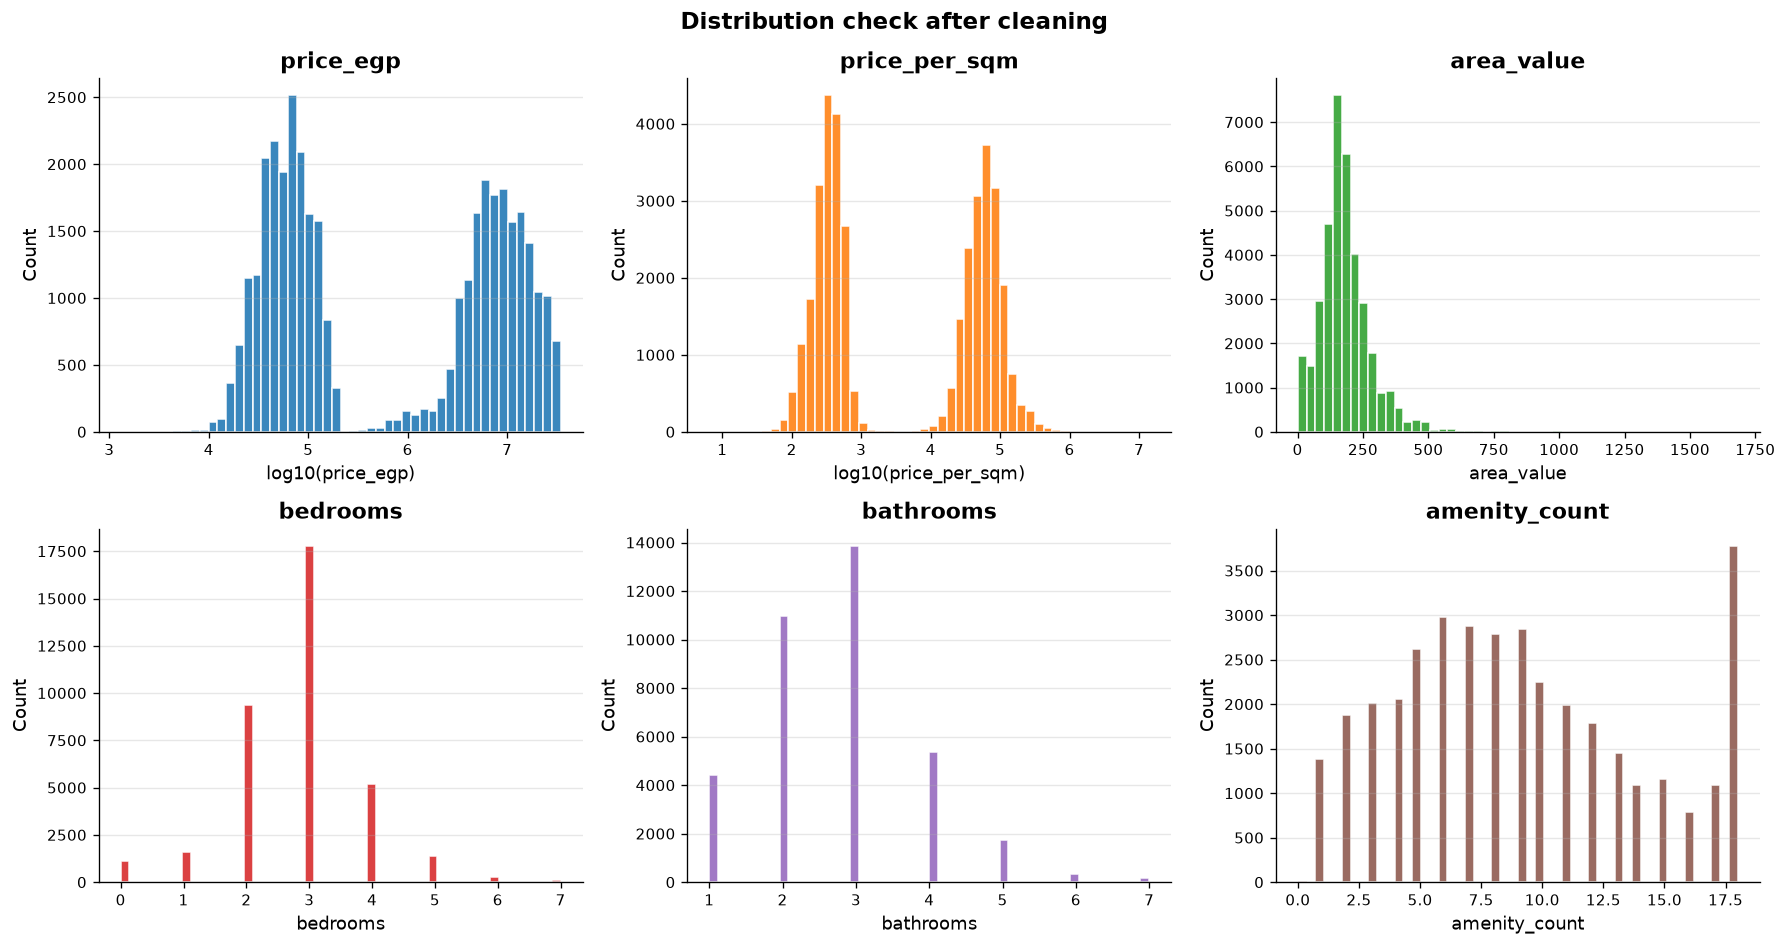

In [33]:
CHECK_COLS = ["price_egp", "price_per_sqm", "area_value",
              "bedrooms", "bathrooms", "amenity_count"]
CHECK_COLS = [c for c in CHECK_COLS if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes      = axes.flatten()

for i, (col, color) in enumerate(zip(CHECK_COLS, palette)):
    data = df[col].dropna()

    if "price" in col:
        data   = np.log10(data + 1)
        xlabel = f"log10({col})"
    else:
        xlabel = col

    axes[i].hist(data, bins=50, color=color, edgecolor="white", alpha=0.88)
    axes[i].set_title(col, fontweight="bold")
    axes[i].set_xlabel(xlabel)
    axes[i].set_ylabel("Count")
    axes[i].grid(axis="y", alpha=0.3)

# hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribution check after cleaning", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "distribution_check.png"), dpi=150, bbox_inches="tight")
plt.show()

## 10. Export the clean data

Two output files:
1. `egypt_re_clean.csv` - the full cleaned dataset, used by all downstream notebooks
2. `egypt_re_amenities_binary.csv` - listing ID plus the 20 amenity columns, for correlation analysis and Power BI

In [34]:
# drop the Python list column before saving (CSV cannot store lists)
export_df  = df.drop(columns=["amenities_list"], errors="ignore")
CLEAN_PATH = os.path.join(OUTPUT_DIR, "egypt_re_clean.csv")

export_df.to_csv(CLEAN_PATH, index=False, encoding="utf-8-sig")

print(f"Saved: {CLEAN_PATH}")
print(f"Shape: {export_df.shape[0]:,} rows x {export_df.shape[1]} columns")
print(f"Size : {os.path.getsize(CLEAN_PATH) / 1_048_576:.1f} MB")

Saved: F:\NTI Adv Data\Final Project\Final_Project_NTI_AdvDataAnalytics\Data\Processed\egypt_re_clean.csv
Shape: 36,870 rows x 70 columns
Size : 54.7 MB


In [35]:
# save a separate file with just the listing ID and amenity columns
id_col = "listing_id" if "listing_id" in df.columns else df.columns[0]

amenity_export = df[[id_col] + amenity_cols].copy()
AMEN_PATH      = os.path.join(OUTPUT_DIR, "egypt_re_amenities_binary.csv")

amenity_export.to_csv(AMEN_PATH, index=False, encoding="utf-8-sig")

print(f"Saved: {AMEN_PATH}")
print(f"Shape: {amenity_export.shape[0]:,} rows x {amenity_export.shape[1]} columns")
print()
print("Amenity prevalence (% of listings with each amenity):")
print(
    (amenity_export[amenity_cols].mean() * 100)
    .round(1)
    .sort_values(ascending=False)
    .to_string()
)

Saved: F:\NTI Adv Data\Final Project\Final_Project_NTI_AdvDataAnalytics\Data\Processed\egypt_re_amenities_binary.csv
Shape: 36,870 rows x 21 columns

Amenity prevalence (% of listings with each amenity):
amen_balcony              93.5000
amen_security             89.4000
amen_covered_parking      62.2000
amen_view_of_landmark     56.7000
amen_shared_gym           55.2000
amen_lobby_in_building    54.6000
amen_central_a_c          54.5000
amen_kitchen_appliances   51.3000
amen_built_in_wardrobes   50.4000
amen_shared_spa           47.8000
amen_shared_pool          47.1000
amen_walk_in_closet       45.1000
amen_study                40.8000
amen_children_s_pool      38.1000
amen_view_of_water        37.5000
amen_private_garden       35.1000
amen_maids_room           31.7000
amen_private_pool         18.1000
amen_networked             0.0000
amen_dining_in_building    0.0000


## 11. Summary

The data is clean and ready for the next notebook.

### Output files

| File | Used by |
|---|---|
| `egypt_re_clean.csv` | 02_eda.ipynb, 04_nlp.ipynb, 05_ml_prediction.ipynb, 06_timeseries.ipynb, Power BI, Tableau |
| `egypt_re_amenities_binary.csv` | 03_outlier_correlation.ipynb, Power BI |

### Decisions made

| Step | What we did | Why |
|---|---|---|
| High-null columns | Dropped columns missing more than 40% (with exceptions) | Too many blanks to fill reliably |
| Duplicates | Kept the most recently scraped row per listing_id | Freshest price and status |
| listed_date | Reassigned across 2022-2026 | All raw dates were in Feb-Mar 2026 (scraper artifact) |
| offering_type | Re-derived from category as Buy or Rent | Raw values were long inconsistent strings |
| price_egp | Removed outliers using IQR, applied separately per type | Buy and Rent have very different price ranges |
| bedrooms / bathrooms | Studio to 0, 10+ to 10, missing to median | Stored as text with special values |
| area_value | Flagged unusual values, did not remove | Let later analysis decide what to do with them |
| furnished | Mapped to three clean categories | Many different raw spellings |
| amenities | Parsed from string, created top-20 binary columns | Needed for correlation and machine learning |
| description | Removed HTML tags and extra whitespace | HTML tags break text analysis |
| New columns | Added price_per_sqm, total_rooms, and others | Required by EDA and ML notebooks |
| Remaining nulls | Numeric to median, text to Unknown | Zero nulls in the output |

Next: open `02_eda.ipynb`.